In [11]:
import pandas as pd


df = pd.read_csv('data/combined_urban_features.csv')
df


# TO DO HERE CORRELATION AND CHECK HOW OUR FAETURES AND WORKING TOGETHER

,city_name,grid_id,target_style,building_count,building_density,avg_building_area,avg_building_perimeter,shape_complexity_ratio,courtyard_index,std_building_area,road_segment_count,total_road_length,avg_road_segment_length,road_density_ratio
0,"Copenhagen Municipality, Denmark",203,XIX_Century_Blocks,79,0.309089,625.622141,133.456632,0.485024,0.909601,0.0,413,15202.912858,36.810927,0.027166
1,"Copenhagen Municipality, Denmark",204,XIX_Century_Blocks,72,0.402768,894.494239,188.085291,0.442985,0.852785,0.0,193,11967.468493,62.007609,0.016127
2,"Copenhagen Municipality, Denmark",205,XIX_Century_Blocks,84,0.321603,612.203486,134.809901,0.342489,0.851486,0.0,241,12326.795463,51.148529,0.019551
3,"Copenhagen Municipality, Denmark",226,XIX_Century_Blocks,55,0.178457,518.827852,117.467782,0.438061,0.912516,0.0,118,8287.629062,70.234145,0.014238
4,"Copenhagen Municipality, Denmark",227,XIX_Century_Blocks,120,0.476144,634.466225,133.359812,0.448434,0.863188,0.0,227,11360.279902,50.045286,0.019982
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
612,"Stavanger, Norway",2192,Modern_Urbanism,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0,0.000000,0.000000,0.000000
613,"Stavanger, Norway",2193,Modern_Urbanism,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0,0.000000,0.000000,0.000000
614,"Stavanger, Norway",2290,Modern_Urbanism,21,0.030489,232.246098,55.942486,0.403712,0.976456,0.0,48,2228.333950,46.423624,0.021541
615,"Stavanger, Norway",2291,Modern_Urbanism,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,6,387.949123,64.658187,0.015466


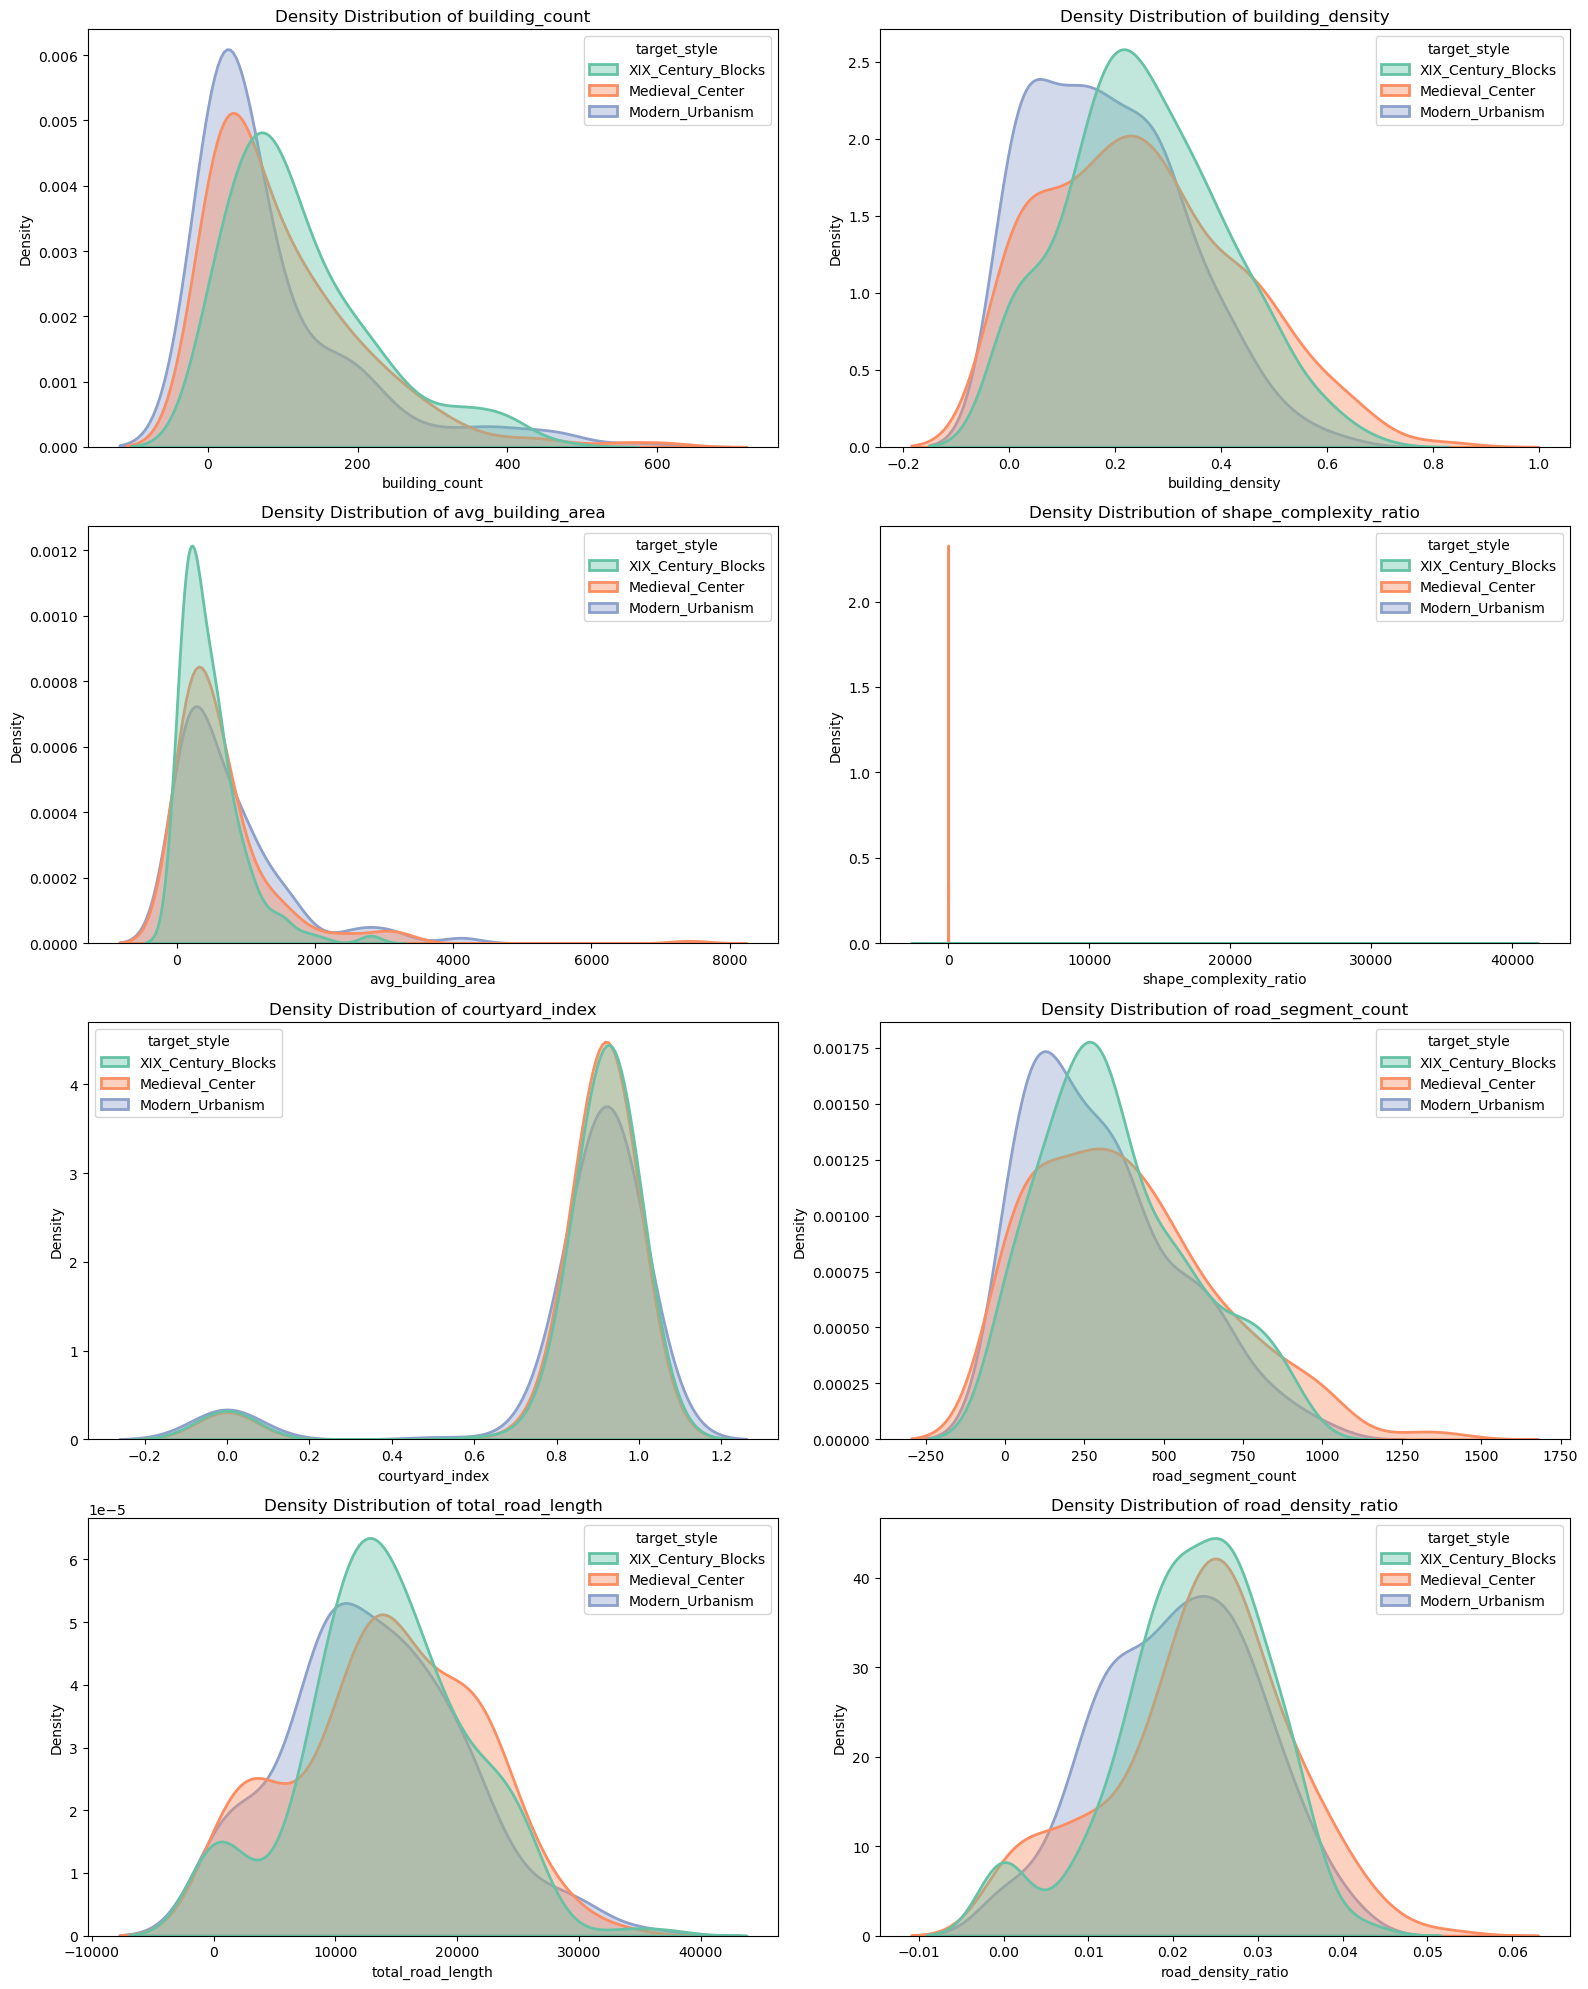

In [15]:
import matplotlib.pyplot as plt 
import seaborn as sns
feature_cols = [
    'building_count', 'building_density', 'avg_building_area', 
    'shape_complexity_ratio', 'courtyard_index', 
    'road_segment_count', 'total_road_length', 'road_density_ratio'
]


fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.kdeplot(
        data=df,
        x=col,
        hue='target_style',
        fill=True,
        common_norm=False,  # Uniezależnia wykres od różnic w liczebności klas
        alpha=0.4,
        linewidth=2,
        palette='Set2',
        ax=axes[i]
    )
    axes[i].set_title(f"Density Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Density")

plt.tight_layout()
plt.show()

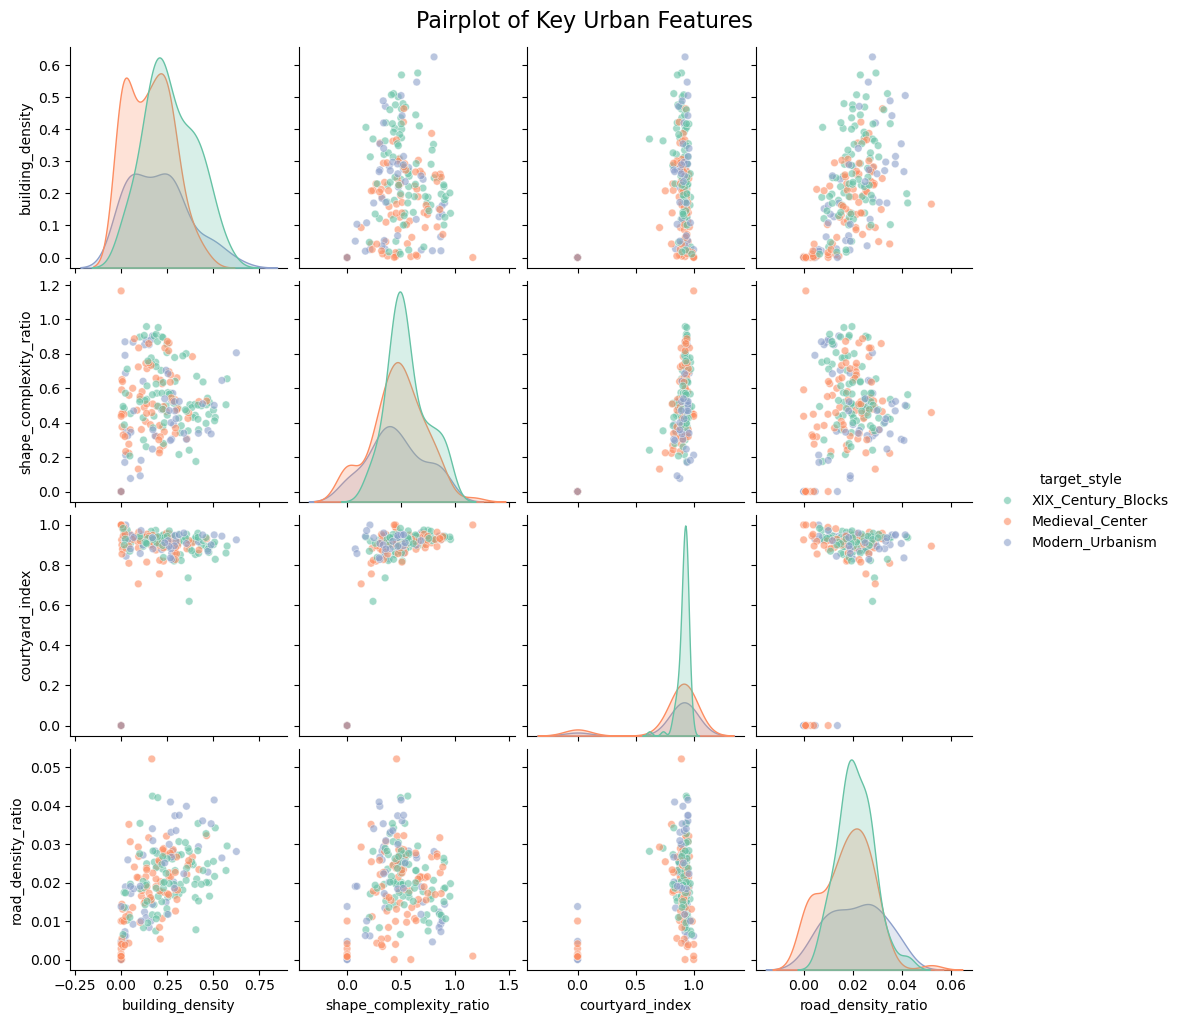

In [3]:

selected_features = ['building_density', 'shape_complexity_ratio', 'courtyard_index', 'road_density_ratio', 'target_style']


sns.pairplot(
    df[selected_features], 
    hue='target_style', 
    palette='Set2', 
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 30}
)
plt.suptitle("Pairplot of Key Urban Features", y=1.02, fontsize=16)
plt.show()

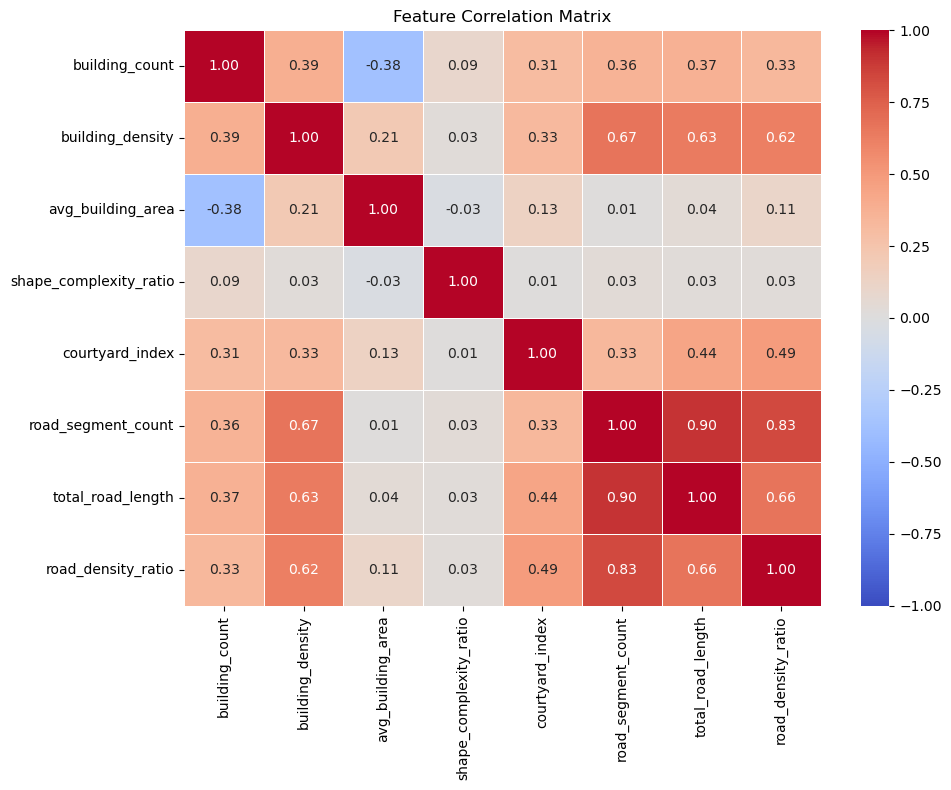

In [13]:
plt.figsize = (10, 8)

corr_matrix = df[feature_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=0.5,
    vmin=-1, vmax=1
)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

Number of samples per class:
target_style
XIX_Century_Blocks    229
Medieval_Center       211
Modern_Urbanism       177
Name: count, dtype: int64

Percentage share per class:
target_style
XIX_Century_Blocks    37.115073
Medieval_Center       34.197731
Modern_Urbanism       28.687196
Name: proportion, dtype: float64


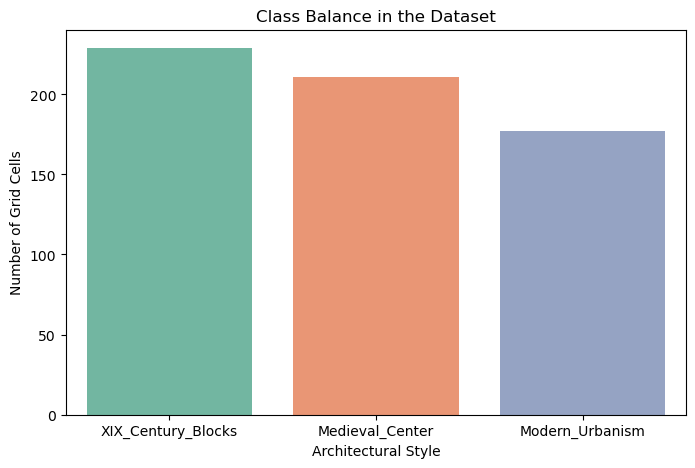

In [14]:
print("Number of samples per class:")
print(df['target_style'].value_counts())

print("\nPercentage share per class:")
print(df['target_style'].value_counts(normalize=True) * 100)

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='target_style', palette='Set2', hue='target_style', legend=False)
plt.title("Class Balance in the Dataset")
plt.ylabel("Number of Grid Cells")
plt.xlabel("Architectural Style")
plt.show()